# DSC 200 Final project

This project involves the analysis of a climate projection of temperature change across the Earth under a 'middle-of-the-road' future scenario in which global mean temperatures reach more than 2 degrees centigrade above the pre-industrial. You will read in the data, analyze it, and visualize it in a variety of ways. You will also write a small command line interface to make the analysis more interactive. 

We will be using data created by the NorESM2 climate model and processed and as part of the ClimateBench [dataset](https://zenodo.org/records/7064308), described in this [paper](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021MS002954). **All the files you will need for this project are available in the `public` folder on DataHub though.**

### Table of contents:

 1. [Read in CO2 emissions data for historical + future scenario](#1-read-in-historical-and-future-estimated-co2-emissions-data) [5 points]
 2. [Read in temperature data](#2-read-in-the-temperature-data) [5 points]
 3. [Create a simple regression model](#3-create-a-simple-regression-model-of-global-warming) [15 points]
 4. [Extend this to a regional temperature model, by region, and by state](#4-extend-this-to-a-regional-temperature-model-by-region-and-by-state) [15 points]
 5. [Plot the regression coefficients for each country](#5-plot-the-regression-coefficients-for-each-country) [5 points]
 6. [Do an analysis of your choosing](#6-do-an-analysis-of-your-choosing) [15 points]
 7. [Make a command line interface](#7-make-a-command-line-interface-to-a-prediction-script) [20 points]
 
### Other requirements:
 You will also be graded on Documentation and commenting, coding style, and code quality:
 - Documentation should be in the form of a Jupyter notebook, and should include a description of the data, the analysis, and the results. [10 points]
 - The code should be well documented, and should follow the PEP8 coding style. [5 points]
 - The code should be well organized, and should be broken up into functions and classes as appropriate. For full marks try to use no for-loops in your code. [5 points]

Be sure to read the question and reach out to the instructor or TA if you have any questions.

### Total points: 100 (30% of total), plus midterm makeup
 - Note, the midterm grade is still capped at 100%

### Deadline: Wednesday December 10th 11:59pm


In [38]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## 1. Read in historical and future (estimated) CO2 emissions data

Monthly CO2 emissions data is available since 1850 globally for each industrial sector. We want to use annual average totals of the emissions for all sectors for our analysis. Since CO2 has a very long lifetime in the atmosphere (1000's of years), we can assume that the total amount of anthropogenic CO2 in the atmosphere is the cumulative sum of all emissions since 1850. This is what we will use for our analysis.

To read this data do **either** Q1a (to get 5 points plus additional makeup points for the midterm) **or** Q1b (to get 5 points for this project)

In [39]:
input_path = "../public/"
# input_path = "public/"

### 1a. OPTIONAL: Create interpolated cumulative CO2 from the raw data using Pandas

To gain (up to) 20% additional marks for your midterm makeup (capped at 100%), you can create a new column in the CO2 emissions data that is the cumulative CO2 emissions. 

In [40]:
# These input files provide CO2 emissions data for the historical period (1850-2014) and the future period (2015-2100). They should all be concatenated into a single file.

historical_input_files = ["CO2_emissions/CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-2017-05-18_gn_200001-201412.csv",
                          'CO2_emissions/CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-2017-05-18_gn_195001-199912.csv',
                          'CO2_emissions/CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-2017-05-18_gn_190001-194912.csv',
                          'CO2_emissions/CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-2017-05-18_gn_185101-189912.csv']

future_input_file = 'CO2_emissions/CO2-em-anthro_input4MIPs_emissions_ScenarioMIP_IAMC-MESSAGE-GLOBIOM-ssp245-1-1_gn_201501-210012.csv'

First you will need to read, concatenate and process the raw CSV files, and sum over the `sector` and `month` columns to get an annual total.

In [41]:
# YOUR CODE HERE
# load and concatenate files in historical_input_files
historical_data = pd.concat([pd.read_csv(input_path + file) for file in historical_input_files], ignore_index=True)

# sum over "sector" and "month" columns to get an annual total for "global_total"
# this can be achieved by just using groupby by "year" and summing "global_total"
annual_historical = historical_data.groupby("year")["global_total"].sum().reset_index()
annual_historical

,year,global_total
0,1851,1.889473e+05
1,1852,1.965696e+05
2,1853,2.050344e+05
3,1854,2.414711e+05
4,1855,2.439077e+05
...,...,...
159,2010,3.218227e+07
160,2011,3.318972e+07
161,2012,3.366014e+07
162,2013,3.465121e+07


**Note**, the future data is only provided every five years so that will need linearly interpolated to get annual values.

In [42]:
# YOUR CODE HERE
# load future data and process similarly
future_data = pd.read_csv(input_path + future_input_file)
annual_future = future_data.groupby("year")["global_total"].sum().reset_index()

# interpolate missing years between 2015 and 2100
annual_future = annual_future.set_index("year").reindex(range(2015, 2101)).interpolate().reset_index()
annual_future

,year,global_total
0,2015,3.487068e+07
1,2016,3.519111e+07
2,2017,3.551154e+07
3,2018,3.583197e+07
4,2019,3.615240e+07
...,...,...
81,2096,1.493869e+07
82,2097,1.434807e+07
83,2098,1.375745e+07
84,2099,1.316683e+07


Now, divide by 1e6 to get the units in GtC (Giga tonnes of carbon) and calculate the cumulative sum.

In [43]:
# YOUR CODE HERE
# concatenate historical and future annual emissions
annual_emissions = pd.concat([annual_historical, annual_future], ignore_index=True)
annual_emissions["global_total"] = annual_emissions["global_total"] / 1e6

# calculate cumulative emissions into new df
cumulative_emissions = annual_emissions.copy()
cumulative_emissions["global_total"] = cumulative_emissions["global_total"].cumsum()
# rename "global_total" column to "cumulative_co2"
cumulative_emissions = cumulative_emissions.rename(columns={"global_total": "cumulative_CO2"})
cumulative_emissions

,year,cumulative_CO2
0,1851,0.188947
1,1852,0.385517
2,1853,0.590551
3,1854,0.832022
4,1855,1.075930
...,...,...
245,2096,4302.526561
246,2097,4316.874630
247,2098,4330.632079
248,2099,4343.798907


Check the data against the existing `combined_co2.csv` and save it to use for the rest of the project.

In [44]:
# YOUR CODE HERE
# check that our cumulative emissions df matches the expected output in 'cumulative_co2.csv'
expected_cumulative = pd.read_csv(input_path + "cumulative_co2.csv")
pd.testing.assert_frame_equal(cumulative_emissions, expected_cumulative)

### 1b. Otherwise just read in the cumulative CO2 emissions data from the provided file

In [45]:
pre_processed_input_file = input_path+'cumulative_co2.csv'

# Read the input files

In [46]:
# YOUR CODE HERE
cumulative_CO2 = pd.read_csv(pre_processed_input_file)
cumulative_CO2

,year,cumulative_CO2
0,1851,0.188947
1,1852,0.385517
2,1853,0.590551
3,1854,0.832022
4,1855,1.075930
...,...,...
245,2096,4302.526561
246,2097,4316.874630
247,2098,4330.632079
248,2099,4343.798907


## 2. Read in the temperature data

Note, this temperature change as modelled by the NorESM2 climate model relative to the pre-industrial period. It's purely driven by the prescribed emissions, so it won't perfect represent the actual temperatures we experienced in a given year (which are subject to chaotic fluctuations), but it's a good model.

In [47]:
temperature_input_file = input_path+'global_temperature.nc'

# Read the input files
## Note, the variable name in the netcdf file is 'tas' (not 'temperature')

In [48]:
# YOUR CODE HERE
# read in netcdf file "temperature_input_file"
temperature_data = xr.open_dataset(temperature_input_file)
temperature_data

<xarray.Dataset> Size: 14MB
Dimensions:   (time: 250, lat: 96, lon: 144)
Coordinates:
  * time      (time) int64 2kB 1851 1852 1853 1854 1855 ... 2097 2098 2099 2100
  * lat       (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    quantile  float64 8B ...
Data variables:
    tas       (time, lat, lon) float32 14MB ...

And take the global mean. Don't forget to calculate and include weights for the latitude of each grid cell.

In [49]:
# YOUR CODE HERE
# take the global mean of temperature, accounting for latitude of each grid cell
weights = np.cos(np.deg2rad(temperature_data["lat"]))
global_mean_temp = temperature_data["tas"].weighted(weights).mean(dim=["lat", "lon"])
global_mean_temp

<xarray.DataArray 'tas' (time: 250)> Size: 2kB
array([ 6.72612374e-02,  1.20035238e-01,  1.92815950e-01,  1.95746039e-01,
        8.08993653e-02,  1.72920985e-01,  2.25773570e-01,  1.69944321e-01,
        6.61424517e-02,  5.21966283e-02,  3.33512396e-02,  7.67547077e-02,
        1.19199507e-01,  2.22590415e-01,  7.06020892e-02, -3.75847833e-04,
        3.97141062e-02,  3.24739600e-01,  2.71118462e-01,  9.36015088e-02,
        5.82252315e-02,  9.86642965e-02,  1.13780169e-01,  6.34739321e-02,
        1.47293307e-01,  1.97818004e-01,  2.85449916e-01,  2.01916945e-01,
        6.62375962e-02,  7.17937239e-02,  1.16519847e-01,  1.18019980e-01,
        1.85678850e-01, -1.52653921e-01,  2.00849461e-02,  6.03316979e-02,
        3.63532523e-02, -6.34130996e-02, -3.71111798e-02,  1.73577156e-01,
        4.02010862e-02, -2.47804956e-02, -1.10920204e-02,  1.49081092e-01,
        1.71308035e-01,  1.04495198e-01,  1.67197942e-01,  1.59396502e-01,
        1.59392914e-01,  1.61038228e-01,  1.31962074e-01,  5.44117564e-03,
       -5.49537461e-02,  4.08114067e-02,  3.14748688e-02,  1.01366049e-01,
        1.83650116e-02,  7.37897515e-02,  2.18975589e-01,  5.29528008e-02,
       -5.51062532e-03, -3.91623960e-02, -1.71177998e-02, -1.17959140e-01,
        3.20987506e-02,  5.74513159e-02, -1.84329588e-02,  9.96872244e-02,
        2.49975685e-01,  2.94183267e-01,  1.95579886e-01,  2.82491804e-01,
        3.19973584e-01,  2.84841497e-01,  3.06335213e-01,  1.99241003e-01,
        3.01548520e-01,  3.49974037e-01,  2.94750302e-01,  2.78432015e-01,
...
        9.00831240e-01,  8.45252087e-01,  9.02879005e-01,  9.36569244e-01,
        9.60462383e-01,  1.07070667e+00,  1.11076983e+00,  1.03452646e+00,
        1.01761192e+00,  1.14364759e+00,  1.07994920e+00,  1.11884070e+00,
        1.18613664e+00,  1.16338594e+00,  1.29047341e+00,  1.42639843e+00,
        1.30764482e+00,  1.23807414e+00,  1.13020370e+00,  1.29443518e+00,
        1.54668998e+00,  1.50085058e+00,  1.34577803e+00,  1.33297494e+00,
        1.40430999e+00,  1.40757833e+00,  1.42872005e+00,  1.40285110e+00,
        1.54269582e+00,  1.66138098e+00,  1.56378022e+00,  1.39987839e+00,
        1.39758879e+00,  1.48157894e+00,  1.66829836e+00,  1.60636213e+00,
        1.62231252e+00,  1.71460917e+00,  1.65752638e+00,  1.64908420e+00,
        1.71204971e+00,  1.76603396e+00,  1.71172225e+00,  1.80854068e+00,
        1.95412314e+00,  1.87063017e+00,  1.83833707e+00,  1.76695209e+00,
        1.80987820e+00,  1.89355241e+00,  1.92653268e+00,  1.97297582e+00,
        1.98228104e+00,  1.91828613e+00,  1.79187373e+00,  1.86555629e+00,
        1.81606824e+00,  1.78737220e+00,  2.03393064e+00,  2.09874396e+00,
        1.90060659e+00,  1.94876167e+00,  2.14332166e+00,  2.12103312e+00,
        2.04069285e+00,  2.02418831e+00,  2.07208779e+00,  2.19144215e+00,
        2.23078161e+00,  2.04971392e+00,  2.07181918e+00,  2.12204225e+00,
        2.11252537e+00,  2.00896052e+00,  2.02257726e+00,  2.18747148e+00,
        2.14751340e+00,  2.16579821e+00])
Coordinates:
  * time      (time) int64 2kB 1851 1852 1853 1854 1855 ... 2097 2098 2099 2100
    quantile  float64 8B 0.9

## 3. Create a simple regression model of global warming

Global warming can be surprisingly well predicted just using a linear model of cumulative CO2 emissions. This is because the CO2 emissions are the primary driver of global warming, and the CO2 stays in the atmosphere for a long time (see e.g. https://www.nature.com/articles/ngeo3031).

To get global temperature as a function of cumulative CO2. You can use the `LinearRegression` class from `sklearn.linear_model`, with documentation provided [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). You should only need to use the `fit` and `predict` methods. The `fit` method takes two arguments, the first is the input data, and the second is the output data. The `predict` method takes one argument, the input data.

Alternatively, you can also use the `statsmodels` package to get more detailed statistics on the regression. See [here](https://www.statsmodels.org/stable/regression.html) for documentation.

Since we're only aiming to create an interpolation model, we don't need to worry too much about keeping a test set aside. We can just use all the data to train the model. You could also use a train-test split if you want to.

In [50]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = cumulative_CO2["cumulative_CO2"].values.reshape(-1, 1)
y = global_mean_temp.values
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Plot global mean temperature as a function of cumulative CO2 emissions, along with the regression fit


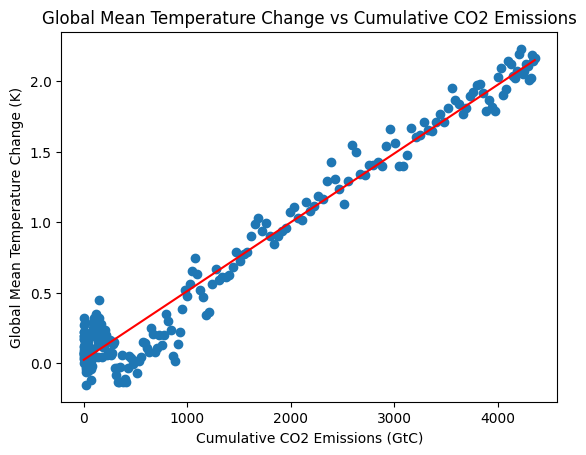

In [51]:
# YOUR CODE HERE
# plot global mean temperature change vs cumulative CO2 emissions
plt.scatter(cumulative_CO2["cumulative_CO2"], global_mean_temp)
# plot linear regression line
x_range = np.linspace(cumulative_CO2["cumulative_CO2"].min(), cumulative_CO2["cumulative_CO2"].max(), 250).reshape(-1, 1)
y_range = model.predict(x_range)
plt.plot(x_range, y_range, color="red")
plt.xlabel("Cumulative CO2 Emissions (GtC)")
plt.ylabel("Global Mean Temperature Change (K)")
plt.title("Global Mean Temperature Change vs Cumulative CO2 Emissions")
plt.show()

Plot global mean temperature as a function of year, along with the regression fit

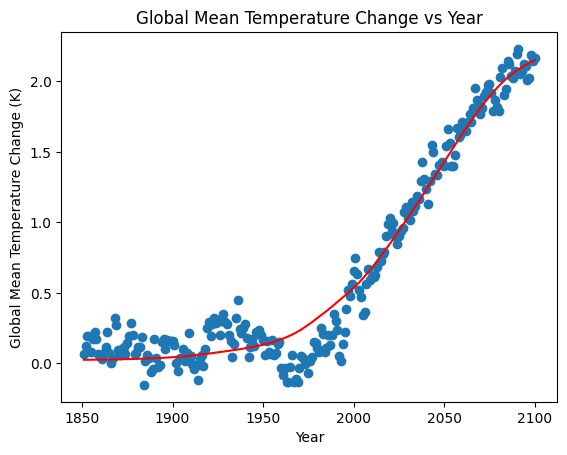

In [52]:
# YOUR CODE HERE
# plot global mean temperature change vs year
plt.scatter(cumulative_CO2["year"], global_mean_temp)
# plot linear regression line
x_years = np.linspace(cumulative_CO2["year"].min(), cumulative_CO2["year"].max(), 250).reshape(-1, 1)
# need to get corresponding cumulative CO2 for these years
cumulative_CO2_for_years = np.interp(x_years.flatten(), cumulative_CO2["year"], cumulative_CO2["cumulative_CO2"])
y_years = model.predict(cumulative_CO2_for_years.reshape(-1, 1))
plt.plot(x_years, y_years, color="red")
plt.xlabel("Year")
plt.ylabel("Global Mean Temperature Change (K)")
plt.title("Global Mean Temperature Change vs Year")
plt.show()

Where does the prediction do well? Where does it do less well? Visualise the residuals.

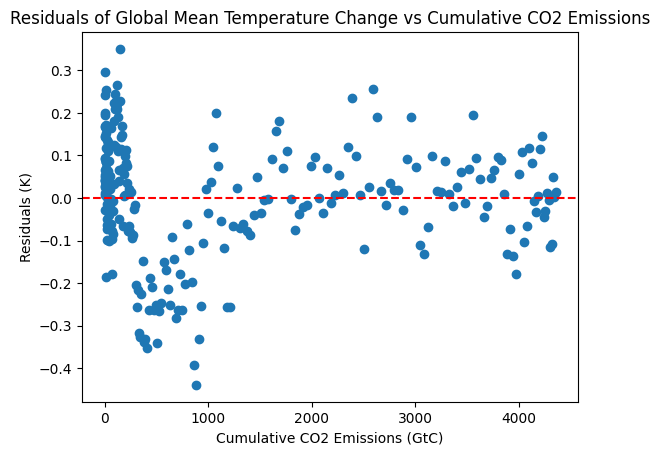

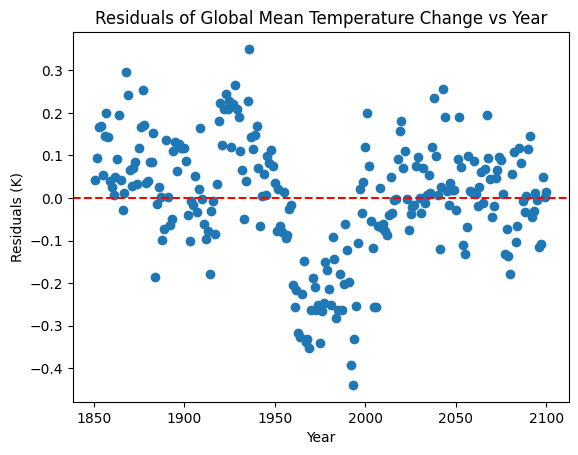

In [53]:
# YOUR CODE HERE
# visualize the residuals of global mean temperature change vs cumulative CO2 emissions
predicted_temps = model.predict(X)
residuals = y - predicted_temps
plt.scatter(cumulative_CO2["cumulative_CO2"], residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Cumulative CO2 Emissions (GtC)")
plt.ylabel("Residuals (K)")
plt.title("Residuals of Global Mean Temperature Change vs Cumulative CO2 Emissions")
plt.show()

# visualize the residuals of global mean temperature vs year
plt.scatter(cumulative_CO2["year"], residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residuals (K)")
plt.title("Residuals of Global Mean Temperature Change vs Year")
plt.show()

## 4. Extend this to a regional temperature model, by region, and by state

While the relationship between global temperature and cumulative CO2 emissions is very linear, the relationship between regional temperature and cumulative CO2 emissions is less so. This is because the regional temperature is affected by other factors, such as the regional distribution of land and ocean, and the regional distribution of CO2 emissions. Nevertheless, let's see how well it can do

Read in the country mask which is a 2D array of the same size as the temperature data, with each grid cell containing the country code of the country that grid cell is in.

In [54]:
country_mask_file = input_path+'country_mask.nc'

In [55]:
# YOUR CODE HERE
country_mask = xr.open_dataarray(country_mask_file)
country_mask

<xarray.DataArray (lat: 96, lon: 144)> Size: 1MB
[13824 values with dtype=<U24]
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

Average the spatial coordinates into countries so that you end up with a dataset that has dimensionality of the number of countries by the number of time points.

In [56]:
# YOUR CODE HERE
tas = temperature_data["tas"]
country_3d = country_mask.expand_dims(time=tas.time)
country_3d = country_3d.transpose("time", "lat", "lon")
results = [tas.where(country_3d == country).weighted(weights).mean(dim=["lat", "lon"]).assign_coords(country=country) for country in np.unique(country_mask.values)]
country_mean_temp = xr.concat(results, dim="country").to_dataset(name="tas")
country_mean_temp

<xarray.Dataset> Size: 316kB
Dimensions:   (time: 250, country: 150)
Coordinates:
  * time      (time) int64 2kB 1851 1852 1853 1854 1855 ... 2097 2098 2099 2100
  * country   (country) <U24 14kB 'Afghanistan' 'Albania' ... 'Zimbabwe'
    quantile  float64 8B 0.9
Data variables:
    tas       (country, time) float64 300kB 0.3534 0.2314 0.579 ... 3.41 3.675

Plot a bar chart of the warming in each country in 2023. Note, the temperature data is baselined to 1850.

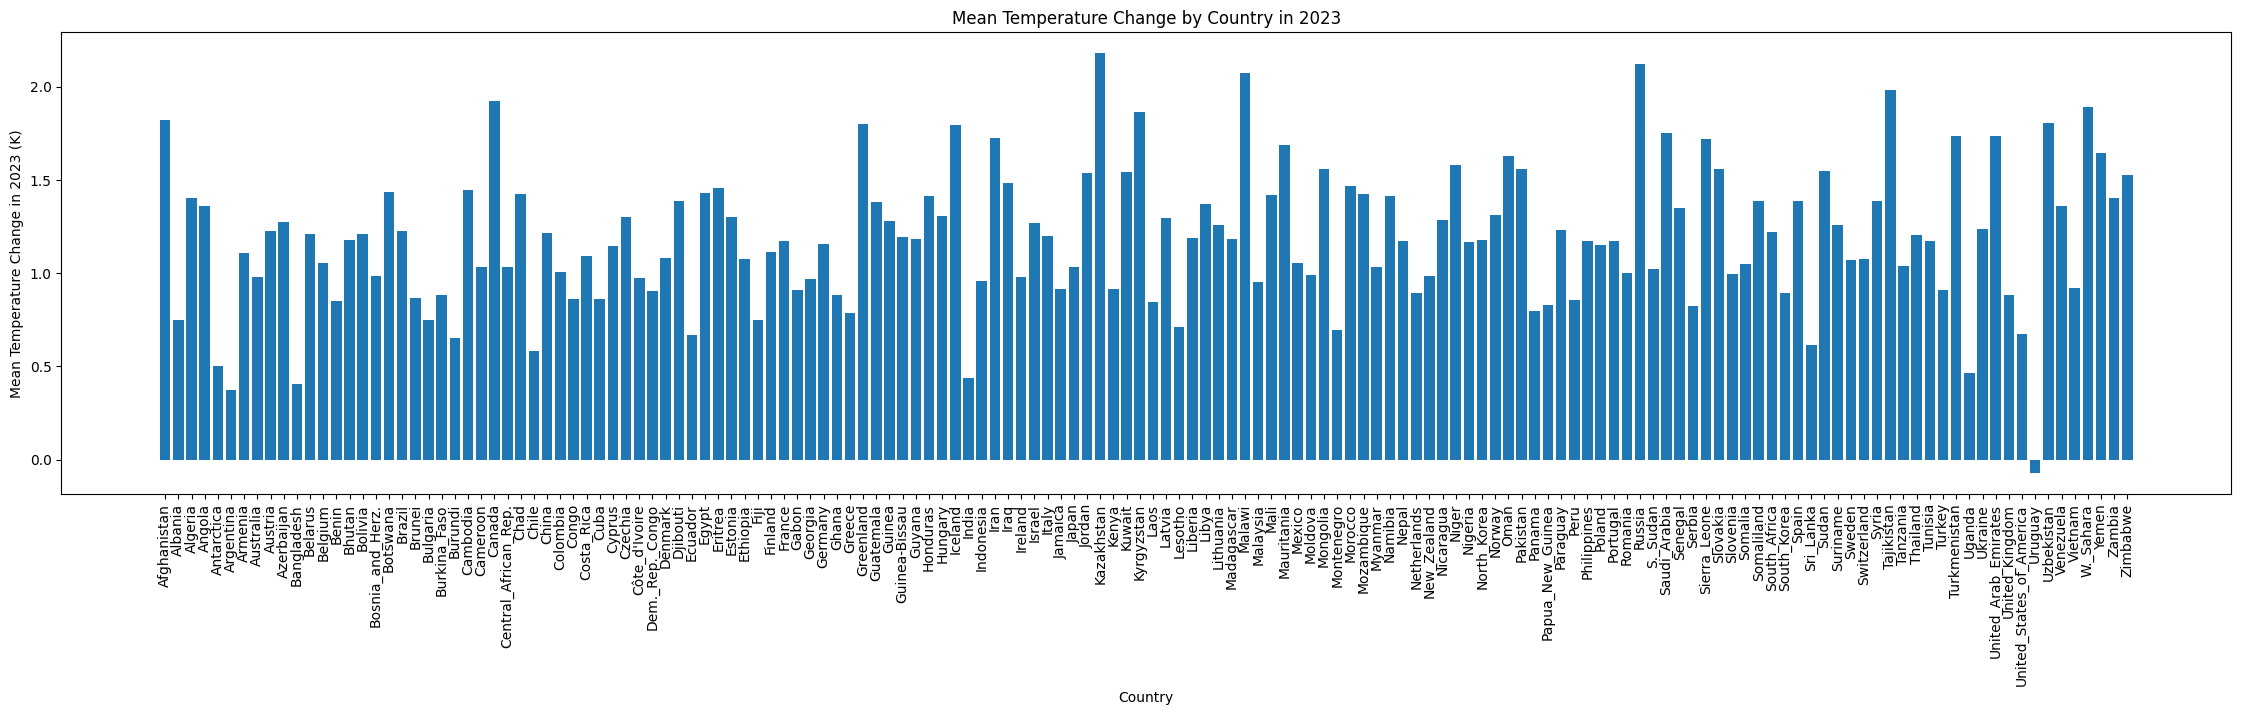

In [58]:
# YOUR CODE HERE
country_mean_temp_2023 = country_mean_temp.sel(time=2023).to_pandas()
country_mean_temp_2023
plt.figure(figsize=(28, 6))
plt.bar(country_mean_temp_2023.index.astype(str), country_mean_temp_2023["tas"])
plt.xlabel("Country")
plt.ylabel("Mean Temperature Change in 2023 (K)")
plt.title("Mean Temperature Change by Country in 2023")
plt.xticks(rotation=90)
plt.show()


Calculate a linear regression model for each country along with the R^2 value. Plot the R^2 values for each country as a bar chart.

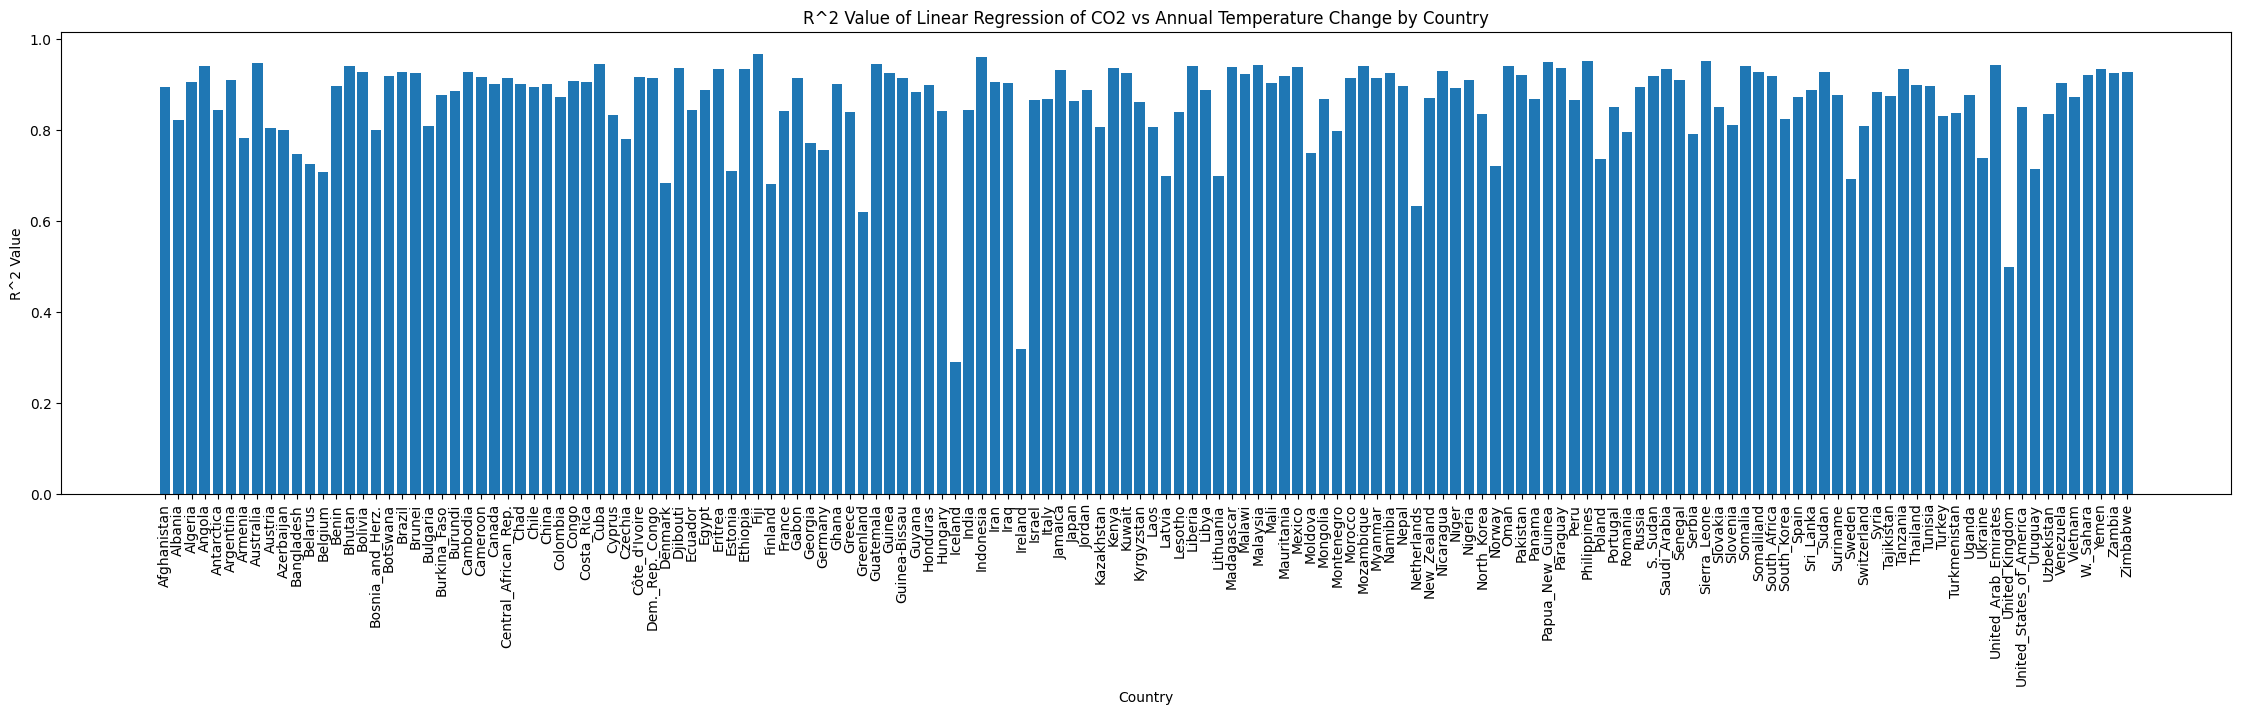

In [59]:
# YOUR CODE HERE
import statsmodels.api as sm

country_regressions = [sm.OLS(country_mean_temp.sel(country=country)["tas"].values, sm.add_constant(X)).fit() for country in np.unique(country_mask.values)]
r2_values = [reg.rsquared for reg in country_regressions]
plt.figure(figsize=(28, 6))
plt.bar(country_mean_temp["country"].values.astype(str), r2_values)
plt.xlabel("Country")
plt.ylabel("R^2 Value")
plt.title("R^2 Value of Linear Regression of CO2 vs Annual Temperature Change by Country")
plt.xticks(rotation=90)
plt.show()

For which countries does the linear assumption work well, and where does it work less well?

YOUR ANSWER HERE

In [60]:
print("Best 5 Fits by R^2 Value:")
for i in np.argsort(r2_values)[-5:][::-1]:
    print("Country: {:<25} R^2 Value: {:.6f}".format(country_mean_temp['country'].values[i], r2_values[i]))

print("Worst 5 Fits by R^2 Value:")
for i in np.argsort(r2_values)[:5]:
    print("Country: {:<25} R^2 Value: {:.6f}".format(country_mean_temp['country'].values[i], r2_values[i]))

Best 5 Fits by R^2 Value:
Country: Fiji                      R^2 Value: 0.966326
Country: Indonesia                 R^2 Value: 0.961282
Country: Philippines               R^2 Value: 0.951688
Country: Sierra_Leone              R^2 Value: 0.950750
Country: Papua_New_Guinea          R^2 Value: 0.948697
Worst 5 Fits by R^2 Value:
Country: Iceland                   R^2 Value: 0.291359
Country: Ireland                   R^2 Value: 0.317873
Country: United_Kingdom            R^2 Value: 0.498131
Country: Greenland                 R^2 Value: 0.619755
Country: Netherlands               R^2 Value: 0.633525


## 5. Plot the regression coefficients for each country


Which five countries are most sensitive to CO2 emissions and hence warming the fastest?

In [61]:
# YOUR CODE HERE
# get index of top 5 countries with highest slope values
slopes = [reg.params[1] for reg in country_regressions]
print("Top 5 Fastest Warming Countries:")
for i in np.argsort(slopes)[-5:][::-1]:
    print("Country: {:<25} Annual Temp Change: {:.6f} K/year".format(country_mean_temp['country'].values[i], slopes[i]))

Top 5 Fastest Warming Countries:
Country: Canada                    Annual Temp Change: 0.001035 K/year
Country: Russia                    Annual Temp Change: 0.000953 K/year
Country: Saudi_Arabia              Annual Temp Change: 0.000932 K/year
Country: United_Arab_Emirates      Annual Temp Change: 0.000912 K/year
Country: Kuwait                    Annual Temp Change: 0.000879 K/year


## 6. Do an analysis of your choosing

Maybe dig into the changes in one particular country, or look at changes in the variability of temperature. Perhaps look at the chances of exceeding certain temperature limits. 

In [62]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

## 7. Make a command line interface to a prediction script 

The inputs should include the name of a country (or global mean) and cumulative CO2 emissions. It should return the predicted temperature change relative to 1850. You can use the `argparse` package to do this. See [here](https://docs.python.org/3/howto/argparse.html) for documentation. Be sure to check for valid inputs.

Also provide the option to save the predictions to a CSV file.

This script should use the regression coefficients learned in the previous step so it doesn't have to use the full model output each time. You could store them in a numpy file, a pandas CSV file, or even JSON. 

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

---
### No action is required below. Your answers for the project should be written **above this line only**.  
*(Do **not** modify or delete the following “YOUR ANSWER HERE” block.)*

You may see a block below that says **"YOUR ANSWER HERE"**. This block is **not for you to fill in** — it is used internally by the TAs to grade the documentation, coding style, and code quality portions of your project.

- Documentation and Explanation — 10 points  
- Code Documentation & Style — 5 points  
- Code Organization & Structure — 5 points  


YOUR ANSWER HERE

YOUR ANSWER HERE

YOUR ANSWER HERE